# Prediksi Diabetes: Perbandingan Random Forest vs KNN vs SVM
## Studi Komparatif dengan Explainable AI (SHAP & LIME)

**Dataset:** [Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset) — Kaggle  
**Algoritma:** Random Forest · K-Nearest Neighbors · Support Vector Machine  
**Fitur Fokus:** `age` · `bmi` · `hypertension` · `HbA1c_level` · `blood_glucose_level`

---

### Alur Pipeline
```
1. INPUT    → Load Dataset + Feature Selection + EDA
2. PROSES   → Data Cleaning + Train-Test Split + ImbPipeline (SMOTE dalam CV)
3. MODEL    → RF | KNN | SVM — Hyperparameter Tuning (RandomizedSearchCV)
4. EVALUASI → Threshold Tuning + ROC/PR Curve + McNemar Test
5. XAI      → SHAP + LIME untuk model terbaik
```

---

### Versi
| Item | Detail |
|------|--------|
| Versi | V2.0 — Multi-Model Comparison |
| Dataset | 100.000 data, ~8.5% kelas positif (diabetes) |
| Strategi Imbalanced | SMOTE di dalam ImbPipeline (no leakage) |
| Threshold Tuning | Youden's J Statistic |
| Statistical Test | McNemar's Test |

---
## ⚙️ Instalasi & Import Library

In [3]:
# ============================================================
# CELL 1: Instalasi Library
# ============================================================
!pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn shap lime kagglehub statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import time

# --- Machine Learning ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# --- Imbalanced Data ---
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# --- Statistical Test ---
from statsmodels.stats.contingency_tables import mcnemar

# --- Explainable AI ---
import shap
import lime
import lime.lime_tabular

warnings.filterwarnings('ignore')

# Konfigurasi visual global
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Konstanta fitur
SELECTED_FEATURES = ['age', 'bmi', 'hypertension', 'HbA1c_level', 'blood_glucose_level']
FEATURE_LABELS    = ['Usia', 'BMI', 'Hipertensi', 'HbA1c', 'Kadar Glukosa']
TARGET            = 'diabetes'

print('Semua library berhasil di-import!')
print(f'Fitur yang digunakan: {SELECTED_FEATURES}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Semua library berhasil di-import!
Fitur yang digunakan: ['age', 'bmi', 'hypertension', 'HbA1c_level', 'blood_glucose_level']


---
# TAHAP 1: INPUT — Load Data & Exploratory Data Analysis


In [4]:
# ============================================================
# CELL 2: Load Dataset dari Kaggle
# ============================================================
import kagglehub

path = kagglehub.dataset_download('iammustafatz/diabetes-prediction-dataset')
csv_file = os.path.join(path, 'diabetes_prediction_dataset.csv')

df_raw = pd.read_csv(csv_file)

print('Dataset berhasil dimuat!')
print(f'Shape   : {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom')
print(f'Kolom   : {df_raw.columns.tolist()}')
print(f'\nPreview:')
display(df_raw.head())
print(f'\nStatistik Deskriptif:')
display(df_raw.describe().round(2))
print(f'\nMissing values per kolom:')
print(df_raw.isnull().sum())
print(f'\nDuplikat: {df_raw.duplicated().sum():,}')

Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
Dataset berhasil dimuat!
Shape   : 100,000 baris x 9 kolom
Kolom   : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Preview:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



Statistik Deskriptif:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.89,0.07,0.04,27.32,5.53,138.06,0.08
std,22.52,0.26,0.19,6.64,1.07,40.71,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.63,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,60.00,0.00,0.00,29.58,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00



Missing values per kolom:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplikat: 3,854


---
## Feature Selection — 5 Fitur Kunci

Dari 8 fitur input, dipilih **5 fitur** berdasarkan relevansi klinis:

| Fitur | Alasan Dipilih |
|-------|----------------|
| `blood_glucose_level` | Kriteria diagnostik langsung WHO — Feature #1 |
| `HbA1c_level` | Rata-rata glukosa 3 bulan — Feature #2 |
| `age` | Risiko meningkat signifikan di atas 45 tahun |
| `bmi` | Obesitas → resistensi insulin |
| `hypertension` | Penanda sindrom metabolik |

**Fitur yang dihapus:**
- `gender` — Perbedaan prevalensi antar gender sangat kecil
- `heart_disease` — Kemungkinan collinear dengan hypertension
- `smoking_history` — Kategori 'No Info' bermasalah secara metodologis

In [5]:
# ============================================================
# CELL 3: Feature Selection & Basic Cleaning
# ============================================================

# Hapus duplikat
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f'Setelah hapus duplikat: {df.shape[0]:,} baris')

# Pilih 5 fitur + target
df = df[SELECTED_FEATURES + [TARGET]].copy()

print(f'\nDataset setelah feature selection:')
print(f'  Shape  : {df.shape}')
print(f'  Fitur  : {SELECTED_FEATURES}')
print(f'  Target : {TARGET}')
print(f'\nDistribusi kelas:')
vc = df[TARGET].value_counts()
total = len(df)
print(f'  Sehat (0)   : {vc[0]:,} ({vc[0]/total*100:.1f}%)')
print(f'  Diabetes (1): {vc[1]:,} ({vc[1]/total*100:.1f}%)')
print(f'  Rasio Imbalanced: {vc[0]/vc[1]:.1f}:1')

print(f'\nStatistik 5 fitur terpilih:')
display(df[SELECTED_FEATURES].describe().round(3))

Setelah hapus duplikat: 96,146 baris

Dataset setelah feature selection:
  Shape  : (96146, 6)
  Fitur  : ['age', 'bmi', 'hypertension', 'HbA1c_level', 'blood_glucose_level']
  Target : diabetes

Distribusi kelas:
  Sehat (0)   : 87,664 (91.2%)
  Diabetes (1): 8,482 (8.8%)
  Rasio Imbalanced: 10.3:1

Statistik 5 fitur terpilih:


,age,bmi,hypertension,HbA1c_level,blood_glucose_level
count,96146.000,96146.000,96146.000,96146.000,96146.000
mean,41.794,27.321,0.078,5.533,138.218
std,22.463,6.768,0.268,1.073,40.910
min,0.080,10.010,0.000,3.500,80.000
25%,24.000,23.400,0.000,4.800,100.000
50%,43.000,27.320,0.000,5.800,140.000
75%,59.000,29.860,0.000,6.200,159.000
max,80.000,95.690,1.000,9.000,300.000


---
## EDA — Visualisasi Distribusi & Karakteristik Data

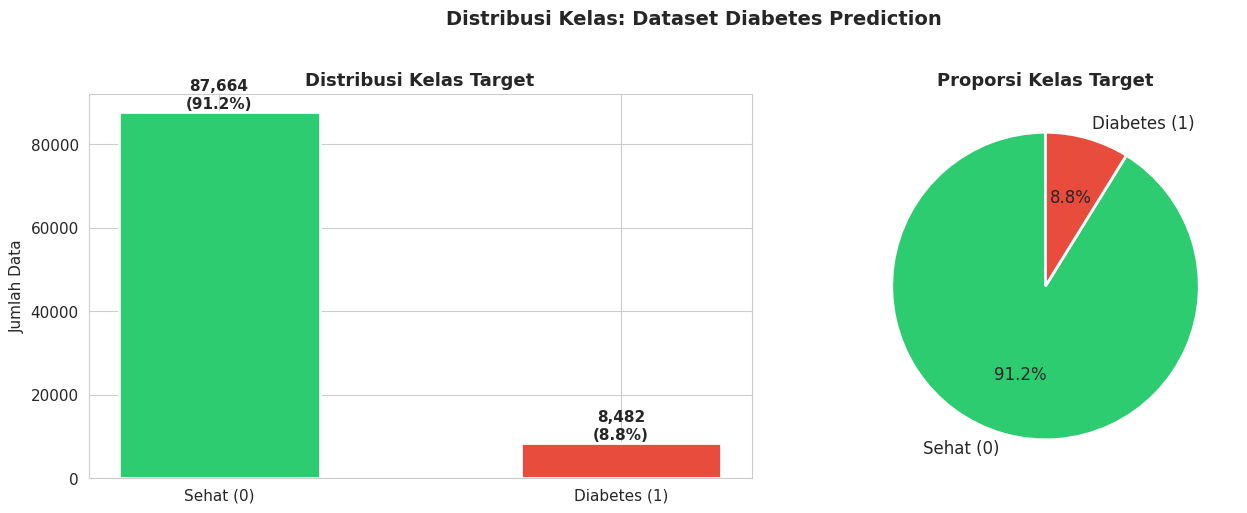

Kelas sangat tidak seimbang (imbalanced) — SMOTE diperlukan!


In [6]:
# ============================================================
# CELL 4: EDA — Distribusi Kelas Target
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']
labels_cls = ['Sehat (0)', 'Diabetes (1)']
counts = df[TARGET].value_counts().sort_index()

# Bar chart
bars = axes[0].bar(labels_cls, counts.values, color=colors, edgecolor='white', linewidth=2, width=0.5)
axes[0].set_title('Distribusi Kelas Target', fontweight='bold')
axes[0].set_ylabel('Jumlah Data')
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
                 f'{count:,}\n({count/total*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels_cls, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Target', fontweight='bold')

plt.suptitle('Distribusi Kelas: Dataset Diabetes Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kelas sangat tidak seimbang (imbalanced) — SMOTE diperlukan!')

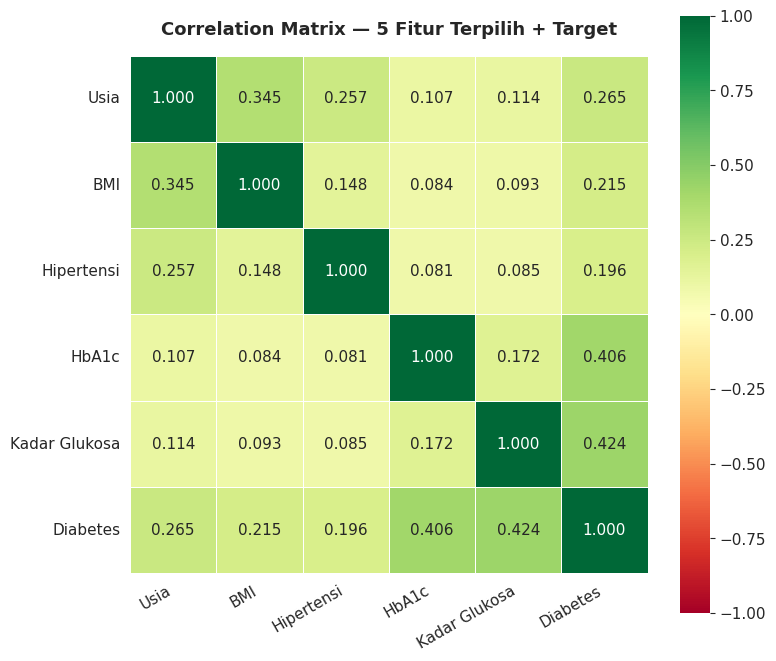

Korelasi tertinggi dengan Diabetes:
  Kadar Glukosa       : 0.424
  HbA1c               : 0.406
  Usia                : 0.265
  BMI                 : 0.215
  Hipertensi          : 0.196


In [7]:
# ============================================================
# CELL 5: EDA — Correlation Matrix (5 Fitur Terpilih)
# ============================================================

corr = df[SELECTED_FEATURES + [TARGET]].corr()

plt.figure(figsize=(8, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, square=True, linewidths=0.5,
    xticklabels=FEATURE_LABELS + ['Diabetes'],
    yticklabels=FEATURE_LABELS + ['Diabetes'],
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix — 5 Fitur Terpilih + Target', fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Korelasi tertinggi dengan Diabetes:')
corr_target = corr[TARGET].drop(TARGET).sort_values(ascending=False)
for feat, val in corr_target.items():
    label = FEATURE_LABELS[SELECTED_FEATURES.index(feat)]
    print(f'  {label:20s}: {val:.3f}')

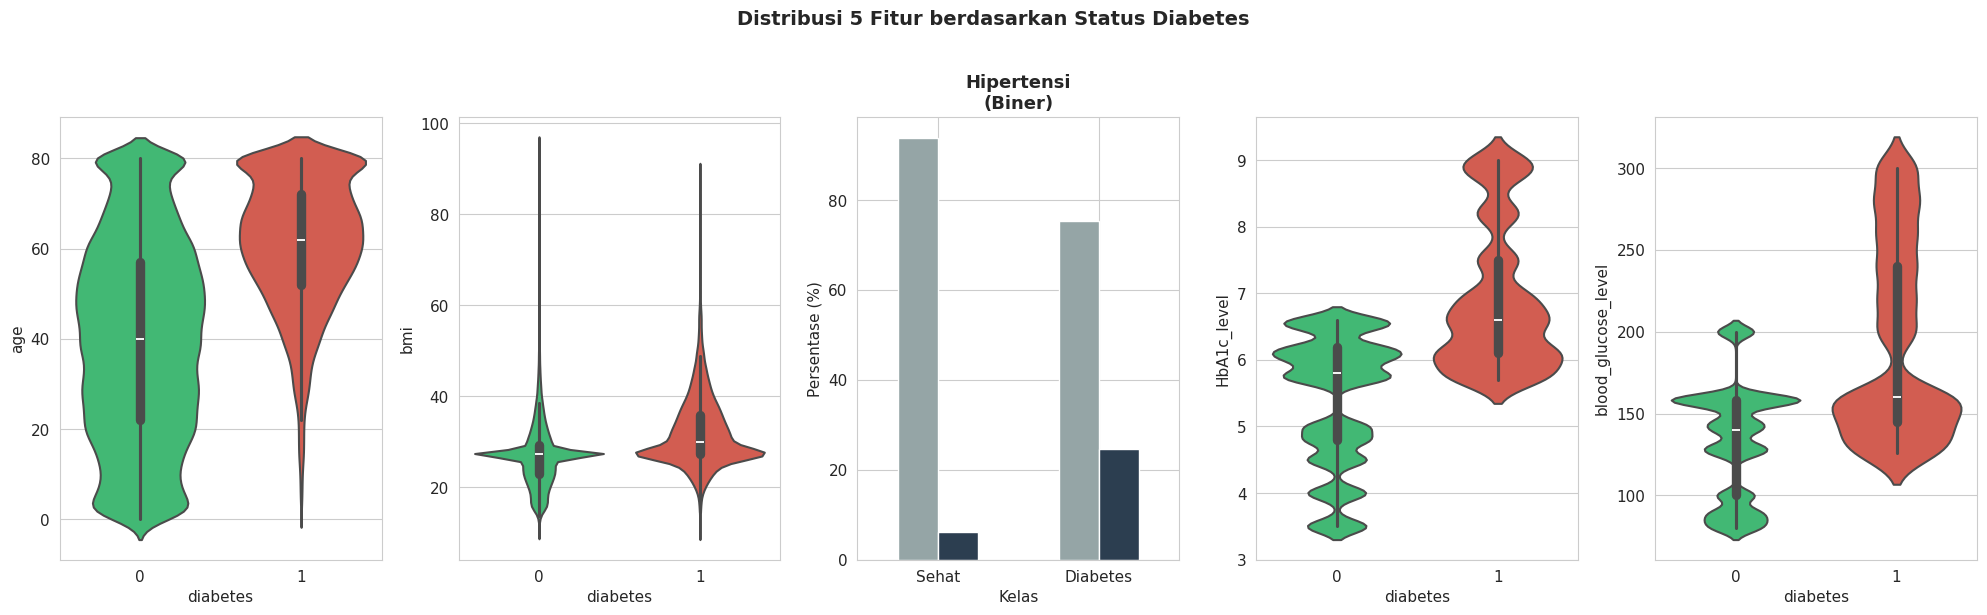

HbA1c dan Kadar Glukosa menunjukkan separasi kelas yang paling jelas.


In [8]:
# ============================================================
# CELL 6: EDA — Distribusi Fitur per Kelas (Violin + Box)
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

palette = {0: '#2ecc71', 1: '#e74c3c'}

for ax, feat, label in zip(axes, SELECTED_FEATURES, FEATURE_LABELS):
    if df[feat].nunique() == 2:  # Binary: hypertension
        ct = df.groupby([TARGET, feat]).size().unstack(fill_value=0)
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
        ct_pct.plot(kind='bar', ax=ax, color=['#95a5a6', '#2c3e50'],
                    legend=False, rot=0, edgecolor='white')
        ax.set_title(f'{label}\n(Biner)', fontweight='bold')
        ax.set_xlabel('Kelas')
        ax.set_ylabel('Persentase (%)')
        ax.set_xticklabels(['Sehat', 'Diabetes'])
    else:
        sns.violinplot(data=df, x=TARGET, y=feat,
               palette=['#2ecc71', '#e74c3c'],  # ← list, bukan dict
               ax=ax, inner='box', linewidth=1.5,
               order=sorted(df[TARGET].unique()))

plt.suptitle('Distribusi 5 Fitur berdasarkan Status Diabetes',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('HbA1c dan Kadar Glukosa menunjukkan separasi kelas yang paling jelas.')

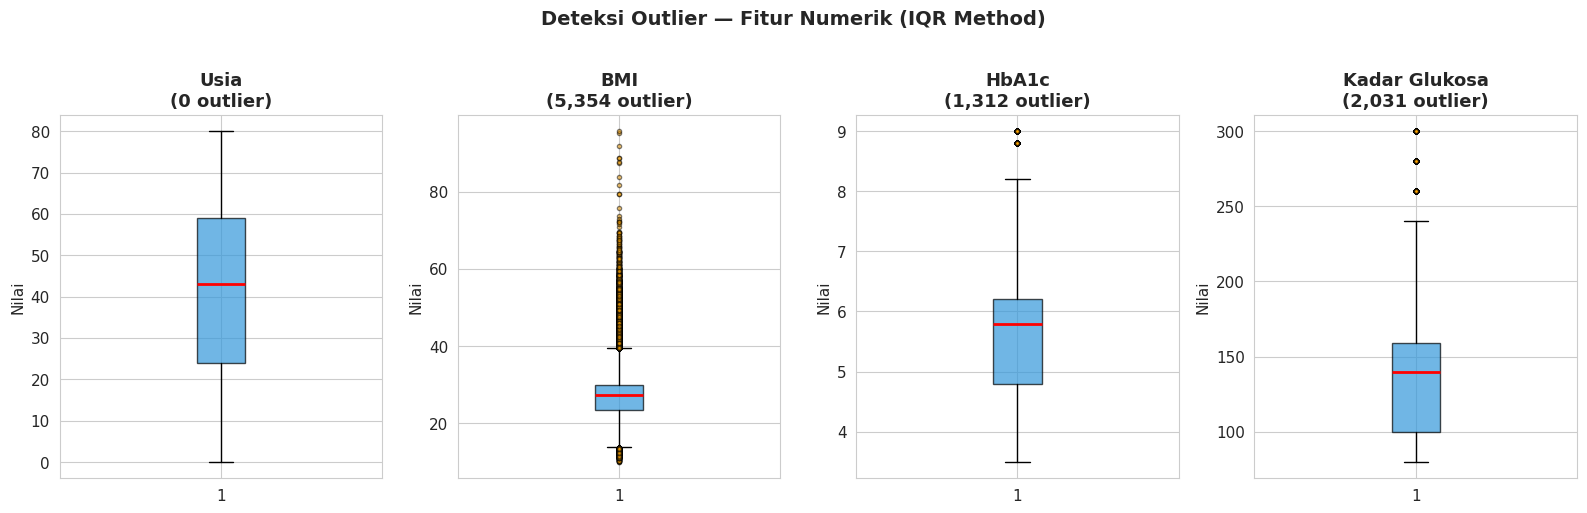

Ringkasan Outlier:
Fitur                      Q1       Q3      IQR    Lower    Upper  N Outlier
---------------------------------------------------------------------------
Usia                    24.00    59.00    35.00   -28.50   111.50          0
BMI                     23.40    29.86     6.46    13.71    39.55      5,354
HbA1c                    4.80     6.20     1.40     2.70     8.30      1,312
Kadar Glukosa          100.00   159.00    59.00    11.50   247.50      2,031


In [9]:
# ============================================================
# CELL 7: EDA — Deteksi Outlier (Boxplot + IQR)
# ============================================================

numeric_feats = [f for f in SELECTED_FEATURES if df[f].nunique() > 2]
numeric_labels = [FEATURE_LABELS[SELECTED_FEATURES.index(f)] for f in numeric_feats]

fig, axes = plt.subplots(1, len(numeric_feats), figsize=(16, 5))

outlier_summary = {}
for ax, feat, label in zip(axes, numeric_feats, numeric_labels):
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[feat] < lower) | (df[feat] > upper)).sum()
    outlier_summary[label] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                               'Lower': lower, 'Upper': upper,
                               'N Outlier': n_outliers}

    ax.boxplot(df[feat], vert=True, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.7),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='orange', markersize=3, alpha=0.5))
    ax.set_title(f'{label}\n({n_outliers:,} outlier)', fontweight='bold')
    ax.set_ylabel('Nilai')

plt.suptitle('Deteksi Outlier — Fitur Numerik (IQR Method)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print('Ringkasan Outlier:')
print(f'{"Fitur":<20} {"Q1":>8} {"Q3":>8} {"IQR":>8} {"Lower":>8} {"Upper":>8} {"N Outlier":>10}')
print('-' * 75)
for label, v in outlier_summary.items():
    print(f'{label:<20} {v["Q1"]:>8.2f} {v["Q3"]:>8.2f} {v["IQR"]:>8.2f} '
          f'{v["Lower"]:>8.2f} {v["Upper"]:>8.2f} {v["N Outlier"]:>10,}')

---
# TAHAP 2: PROSES — Preprocessing & Pemodelan


In [10]:
# ============================================================
# CELL 8: Data Cleaning — Winsorization (Capping Outlier IQR)
# ============================================================

print('DATA CLEANING — WINSORIZATION')
print('=' * 60)

df_clean = df.copy()

# Winsorization hanya untuk fitur numerik (bukan biner)
for feat in numeric_feats:
    Q1 = df_clean[feat].quantile(0.25)
    Q3 = df_clean[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before_low  = (df_clean[feat] < lower).sum()
    before_high = (df_clean[feat] > upper).sum()

    df_clean[feat] = df_clean[feat].clip(lower=lower, upper=upper)

    label = FEATURE_LABELS[SELECTED_FEATURES.index(feat)]
    print(f'  {label:<20}: {before_low+before_high:>4} outlier di-cap '
          f'[{lower:.2f}, {upper:.2f}]')

print(f'\nShape setelah cleaning: {df_clean.shape}')
print('Tidak ada data yang dihapus — hanya nilai ekstrem yang di-cap.')
print(f'\nStatistik setelah Winsorization:')
display(df_clean[SELECTED_FEATURES].describe().round(3))

DATA CLEANING — WINSORIZATION
  Usia                :    0 outlier di-cap [-28.50, 111.50]
  BMI                 : 5354 outlier di-cap [13.71, 39.55]
  HbA1c               : 1312 outlier di-cap [2.70, 8.30]
  Kadar Glukosa       : 2031 outlier di-cap [11.50, 247.50]

Shape setelah cleaning: (96146, 6)
Tidak ada data yang dihapus — hanya nilai ekstrem yang di-cap.

Statistik setelah Winsorization:


,age,bmi,hypertension,HbA1c_level,blood_glucose_level
count,96146.000,96146.000,96146.000,96146.000,96146.000
mean,41.794,27.031,0.078,5.524,137.524
std,22.463,5.920,0.268,1.050,38.640
min,0.080,13.710,0.000,3.500,80.000
25%,24.000,23.400,0.000,4.800,100.000
50%,43.000,27.320,0.000,5.800,140.000
75%,59.000,29.860,0.000,6.200,159.000
max,80.000,39.550,1.000,8.300,247.500


In [11]:
# ============================================================
# CELL 9: Stratified Train-Test Split (80:20)
# PENTING: Split SEBELUM apapun — scaler & SMOTE masuk pipeline!
# ============================================================

X = df_clean[SELECTED_FEATURES].copy()
y = df_clean[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('STRATIFIED TRAIN-TEST SPLIT')
print('=' * 50)
print(f'Total data     : {len(X):,}')
print(f'Training set   : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set       : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)')

print(f'\nDistribusi kelas (Training):')
vc_train = y_train.value_counts().sort_index()
print(f'  Sehat (0)   : {vc_train[0]:,} ({vc_train[0]/len(y_train)*100:.1f}%)')
print(f'  Diabetes (1): {vc_train[1]:,} ({vc_train[1]/len(y_train)*100:.1f}%)')

print(f'\nDistribusi kelas (Test):')
vc_test = y_test.value_counts().sort_index()
print(f'  Sehat (0)   : {vc_test[0]:,} ({vc_test[0]/len(y_test)*100:.1f}%)')
print(f'  Diabetes (1): {vc_test[1]:,} ({vc_test[1]/len(y_test)*100:.1f}%)')
print()
print('StandardScaler dan SMOTE akan diterapkan di dalam ImbPipeline.')
print('Ini mencegah data leakage ke dalam cross-validation!')

STRATIFIED TRAIN-TEST SPLIT
Total data     : 96,146
Training set   : 76,916 (80%)
Test set       : 19,230  (20%)

Distribusi kelas (Training):
  Sehat (0)   : 70,130 (91.2%)
  Diabetes (1): 6,786 (8.8%)

Distribusi kelas (Test):
  Sehat (0)   : 17,534 (91.2%)
  Diabetes (1): 1,696 (8.8%)

StandardScaler dan SMOTE akan diterapkan di dalam ImbPipeline.
Ini mencegah data leakage ke dalam cross-validation!


---
## Pipeline Construction — ImbPipeline (Anti Data Leakage)

Setiap pipeline menggunakan **`imblearn.pipeline.Pipeline`** (bukan sklearn)  
sehingga **SMOTE hanya aktif saat `fit()`**, tidak saat `predict()` atau dalam validation fold CV.

```
ImbPipeline RF  : StandardScaler → SMOTE → RandomForestClassifier
ImbPipeline KNN : StandardScaler → SMOTE → KNeighborsClassifier(kd_tree)
ImbPipeline SVM : StandardScaler → SMOTE → LinearSVC + CalibratedClassifierCV
```

In [12]:
# ============================================================
# CELL 10: Definisi 3 ImbPipeline
# ============================================================

# --- Pipeline 1: Random Forest ---
rf_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=RANDOM_STATE)),
    ('clf',    RandomForestClassifier(
                   class_weight='balanced',
                   random_state=RANDOM_STATE,
                   n_jobs=-1
               ))
])

# --- Pipeline 2: KNN ---
# kd_tree wajib untuk dataset 100K (jauh lebih cepat dari brute force)
knn_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=RANDOM_STATE)),
    ('clf',    KNeighborsClassifier(
                   algorithm='kd_tree',
                   leaf_size=30,
                   n_jobs=-1
               ))
])

# --- Pipeline 3: SVM (LinearSVC + CalibratedClassifierCV) ---
# LinearSVC jauh lebih cepat dari SVC(kernel='rbf') untuk n=100K
# CalibratedClassifierCV diperlukan agar predict_proba tersedia
svm_base = LinearSVC(
    class_weight='balanced',
    max_iter=2000,
    dual=False,       # lebih cepat saat n_samples > n_features
    random_state=RANDOM_STATE
)
svm_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=RANDOM_STATE)),
    ('clf',    CalibratedClassifierCV(svm_base, cv=3))
])

print('3 ImbPipeline berhasil dibuat:')
print('  1. RF  Pipeline: StandardScaler -> SMOTE -> RandomForestClassifier')
print('  2. KNN Pipeline: StandardScaler -> SMOTE -> KNeighborsClassifier(kd_tree)')
print('  3. SVM Pipeline: StandardScaler -> SMOTE -> LinearSVC + Calibration')
print()
print('SMOTE hanya aktif selama training (fit), tidak di validation fold atau test.')

3 ImbPipeline berhasil dibuat:
  1. RF  Pipeline: StandardScaler -> SMOTE -> RandomForestClassifier
  2. KNN Pipeline: StandardScaler -> SMOTE -> KNeighborsClassifier(kd_tree)
  3. SVM Pipeline: StandardScaler -> SMOTE -> LinearSVC + Calibration

SMOTE hanya aktif selama training (fit), tidak di validation fold atau test.


---
# TAHAP 3: Hyperparameter Tuning

**Strategi:**
- `RandomizedSearchCV` dengan `StratifiedKFold(5)`
- Scoring utama: **`recall`** (prioritas deteksi diabetes, false negative lebih berbahaya)
- Random search lebih efisien dari grid search untuk dataset besar


In [13]:
# ============================================================
# CELL 11: Hyperparameter Tuning — Random Forest
# ============================================================

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_param_dist = {
    'clf__n_estimators'    : [100, 200, 300, 500],
    'clf__max_depth'       : [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf' : [1, 2, 4],
    'clf__max_features'    : ['sqrt', 'log2'],
    'clf__criterion'       : ['gini', 'entropy'],
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True
)

print('Training Random Forest (RandomizedSearchCV, 30 iter x 5 fold = 150 fit)...')
t0 = time.time()
rf_search.fit(X_train, y_train)
rf_train_time = time.time() - t0

print(f'\nSelesai dalam {rf_train_time:.1f} detik')
print(f'Best Recall CV : {rf_search.best_score_:.4f}')
print(f'Best Params    :')
for k, v in rf_search.best_params_.items():
    print(f'  {k}: {v}')

best_rf = rf_search.best_estimator_

Training Random Forest (RandomizedSearchCV, 30 iter x 5 fold = 150 fit)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Selesai dalam 5132.6 detik
Best Recall CV : 0.9024
Best Params    :
  clf__n_estimators: 200
  clf__min_samples_split: 5
  clf__min_samples_leaf: 4
  clf__max_features: log2
  clf__max_depth: 10
  clf__criterion: entropy


In [14]:
# ============================================================
# CELL 12: Hyperparameter Tuning — KNN
# ============================================================

knn_param_dist = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'clf__weights'    : ['uniform', 'distance'],
    'clf__metric'     : ['euclidean', 'manhattan'],
    'clf__leaf_size'  : [20, 30, 40],
}

knn_search = RandomizedSearchCV(
    knn_pipeline,
    param_distributions=knn_param_dist,
    n_iter=20,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True
)

print('Training KNN (RandomizedSearchCV, 20 iter x 5 fold = 100 fit)...')
t0 = time.time()
knn_search.fit(X_train, y_train)
knn_train_time = time.time() - t0

print(f'\nSelesai dalam {knn_train_time:.1f} detik')
print(f'Best Recall CV : {knn_search.best_score_:.4f}')
print(f'Best Params    :')
for k, v in knn_search.best_params_.items():
    print(f'  {k}: {v}')

best_knn = knn_search.best_estimator_

Training KNN (RandomizedSearchCV, 20 iter x 5 fold = 100 fit)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Selesai dalam 539.1 detik
Best Recall CV : 0.8803
Best Params    :
  clf__weights: uniform
  clf__n_neighbors: 21
  clf__metric: euclidean
  clf__leaf_size: 20


In [15]:
# ============================================================
# CELL 13: Hyperparameter Tuning — SVM (LinearSVC)
# ============================================================

# Parameter C ada di dalam estimator LinearSVC yang dibungkus CalibratedClassifierCV
svm_param_dist = {
    'clf__estimator__C'       : [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__estimator__max_iter': [1000, 2000, 3000],
}

svm_search = RandomizedSearchCV(
    svm_pipeline,
    param_distributions=svm_param_dist,
    n_iter=15,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True
)

print('Training SVM (RandomizedSearchCV, 15 iter x 5 fold = 75 fit)...')
t0 = time.time()
svm_search.fit(X_train, y_train)
svm_train_time = time.time() - t0

print(f'\nSelesai dalam {svm_train_time:.1f} detik')
print(f'Best Recall CV : {svm_search.best_score_:.4f}')
print(f'Best Params    :')
for k, v in svm_search.best_params_.items():
    print(f'  {k}: {v}')

best_svm = svm_search.best_estimator_

Training SVM (RandomizedSearchCV, 15 iter x 5 fold = 75 fit)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Selesai dalam 32.1 detik
Best Recall CV : 0.8843
Best Params    :
  clf__estimator__max_iter: 3000
  clf__estimator__C: 0.1


In [16]:
# ============================================================
# CELL 14: Ringkasan Best Parameters Semua Model
# ============================================================

print('RINGKASAN BEST PARAMETERS')
print('=' * 60)

models_info = [
    ('Random Forest', rf_search, rf_train_time),
    ('KNN',           knn_search, knn_train_time),
    ('SVM (Linear)',  svm_search, svm_train_time),
]

for name, search, train_time in models_info:
    print(f'\n{name}:')
    print(f'  Best Recall (CV): {search.best_score_:.4f}')
    print(f'  Training Time   : {train_time:.1f}s')
    print(f'  Best Params     :')
    for k, v in search.best_params_.items():
        print(f'    {k.replace("clf__","").replace("estimator__","")}: {v}')

RINGKASAN BEST PARAMETERS

Random Forest:
  Best Recall (CV): 0.9024
  Training Time   : 5132.6s
  Best Params     :
    n_estimators: 200
    min_samples_split: 5
    min_samples_leaf: 4
    max_features: log2
    max_depth: 10
    criterion: entropy

KNN:
  Best Recall (CV): 0.8803
  Training Time   : 539.1s
  Best Params     :
    weights: uniform
    n_neighbors: 21
    metric: euclidean
    leaf_size: 20

SVM (Linear):
  Best Recall (CV): 0.8843
  Training Time   : 32.1s
  Best Params     :
    max_iter: 3000
    C: 0.1


---
# TAHAP 4: Evaluasi & Perbandingan Model

**Langkah:**
1. Evaluasi default threshold (0.5)
2. Threshold tuning dengan Youden's J Statistic
3. Tabel perbandingan metrik
4. ROC Curve + Precision-Recall Curve (3 model dalam 1 plot)
5. Confusion Matrix (3 model)
6. McNemar's Statistical Significance Test


In [17]:
# ============================================================
# CELL 15: Fungsi Evaluasi Lengkap (reusable untuk 3 model)
# ============================================================

def evaluate_model(model, X_test, y_test, model_name, find_threshold=True):
    """
    Evaluasi komprehensif untuk satu model.
    Returns: dict metrics, y_proba, y_pred_tuned
    """
    # Prediksi probabilitas
    y_proba = model.predict_proba(X_test)[:, 1]

    # Threshold Tuning: Youden's J
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    if find_threshold:
        youden_j = tpr - fpr
        opt_idx = np.argmax(youden_j)
        opt_threshold = thresholds[opt_idx]
    else:
        opt_threshold = 0.5

    y_pred_default = (y_proba >= 0.5).astype(int)
    y_pred_tuned   = (y_proba >= opt_threshold).astype(int)

    def metrics(y_pred):
        return {
            'accuracy' : accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall'   : recall_score(y_test, y_pred, zero_division=0),
            'f1'       : f1_score(y_test, y_pred, zero_division=0),
        }

    m_default = metrics(y_pred_default)
    m_tuned   = metrics(y_pred_tuned)
    roc_auc   = roc_auc_score(y_test, y_proba)
    ap_score  = average_precision_score(y_test, y_proba)

    result = {
        'model'         : model_name,
        'threshold'     : opt_threshold,
        'roc_auc'       : roc_auc,
        'ap_score'      : ap_score,
        **{f'{k}_default': v for k, v in m_default.items()},
        **{f'{k}_tuned'  : v for k, v in m_tuned.items()},
    }

    print(f'\n{"="*55}')
    print(f'EVALUASI: {model_name}')
    print(f'{"="*55}')
    print(f'ROC-AUC     : {roc_auc:.4f}')
    print(f'AP Score    : {ap_score:.4f}')
    print(f'\n[Threshold = 0.5 (Default)]')
    print(classification_report(y_test, y_pred_default,
                                target_names=['Sehat', 'Diabetes']))
    print(f'[Threshold = {opt_threshold:.4f} (Youden-tuned)]')
    print(classification_report(y_test, y_pred_tuned,
                                target_names=['Sehat', 'Diabetes']))

    return result, y_proba, y_pred_tuned

print('Fungsi evaluate_model siap digunakan.')

Fungsi evaluate_model siap digunakan.


In [18]:
# ============================================================
# CELL 16: Evaluasi Semua 3 Model
# ============================================================

rf_result,  rf_proba,  rf_pred  = evaluate_model(best_rf,  X_test, y_test, 'Random Forest')
knn_result, knn_proba, knn_pred = evaluate_model(best_knn, X_test, y_test, 'KNN')
svm_result, svm_proba, svm_pred = evaluate_model(best_svm, X_test, y_test, 'SVM (Linear)')


EVALUASI: Random Forest
ROC-AUC     : 0.9733
AP Score    : 0.8695

[Threshold = 0.5 (Default)]
              precision    recall  f1-score   support

       Sehat       0.99      0.89      0.94     17534
    Diabetes       0.45      0.90      0.60      1696

    accuracy                           0.89     19230
   macro avg       0.72      0.90      0.77     19230
weighted avg       0.94      0.89      0.91     19230

[Threshold = 0.4965 (Youden-tuned)]
              precision    recall  f1-score   support

       Sehat       0.99      0.89      0.94     17534
    Diabetes       0.45      0.91      0.60      1696

    accuracy                           0.89     19230
   macro avg       0.72      0.90      0.77     19230
weighted avg       0.94      0.89      0.91     19230


EVALUASI: KNN
ROC-AUC     : 0.9524
AP Score    : 0.7976

[Threshold = 0.5 (Default)]
              precision    recall  f1-score   support

       Sehat       0.99      0.89      0.94     17534
    Diabetes       

In [19]:
# ============================================================
# CELL 17: Tabel Perbandingan Metrik Semua Model
# ============================================================

results = [rf_result, knn_result, svm_result]

# Tabel 1: Metrik Default Threshold
rows_default = []
for r in results:
    rows_default.append({
        'Model'    : r['model'],
        'Accuracy' : f"{r['accuracy_default']:.4f}",
        'Precision': f"{r['precision_default']:.4f}",
        'Recall'   : f"{r['recall_default']:.4f}",
        'F1-Score' : f"{r['f1_default']:.4f}",
        'ROC-AUC'  : f"{r['roc_auc']:.4f}",
        'AP Score' : f"{r['ap_score']:.4f}",
    })

# Tabel 2: Metrik Tuned Threshold
rows_tuned = []
for r in results:
    rows_tuned.append({
        'Model'          : r['model'],
        'Threshold'      : f"{r['threshold']:.4f}",
        'Accuracy'       : f"{r['accuracy_tuned']:.4f}",
        'Precision'      : f"{r['precision_tuned']:.4f}",
        'Recall (utama)' : f"{r['recall_tuned']:.4f}",
        'F1-Score'       : f"{r['f1_tuned']:.4f}",
        'ROC-AUC'        : f"{r['roc_auc']:.4f}",
    })

df_compare_default = pd.DataFrame(rows_default)
df_compare_tuned   = pd.DataFrame(rows_tuned)

print('PERBANDINGAN METRIK — Threshold Default (0.5)')
print('=' * 70)
display(df_compare_default.set_index('Model'))

print('\nPERBANDINGAN METRIK — Threshold Optimal (Youden\'s J)')
print('=' * 70)
display(df_compare_tuned.set_index('Model'))

PERBANDINGAN METRIK — Threshold Default (0.5)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,AP Score
Model,,,,,,
Random Forest,0.8943,0.4505,0.9021,0.6009,0.9733,0.8695
KNN,0.8877,0.4318,0.8644,0.5759,0.9524,0.7976
SVM (Linear),0.8790,0.4127,0.8797,0.5619,0.9581,0.8063



PERBANDINGAN METRIK — Threshold Optimal (Youden's J)


,Threshold,Accuracy,Precision,Recall (utama),F1-Score,ROC-AUC
Model,,,,,,
Random Forest,0.4965,0.8933,0.4481,0.9057,0.5995,0.9733
KNN,0.3810,0.8559,0.3710,0.9121,0.5274,0.9524
SVM (Linear),0.4951,0.8775,0.4097,0.8833,0.5598,0.9581


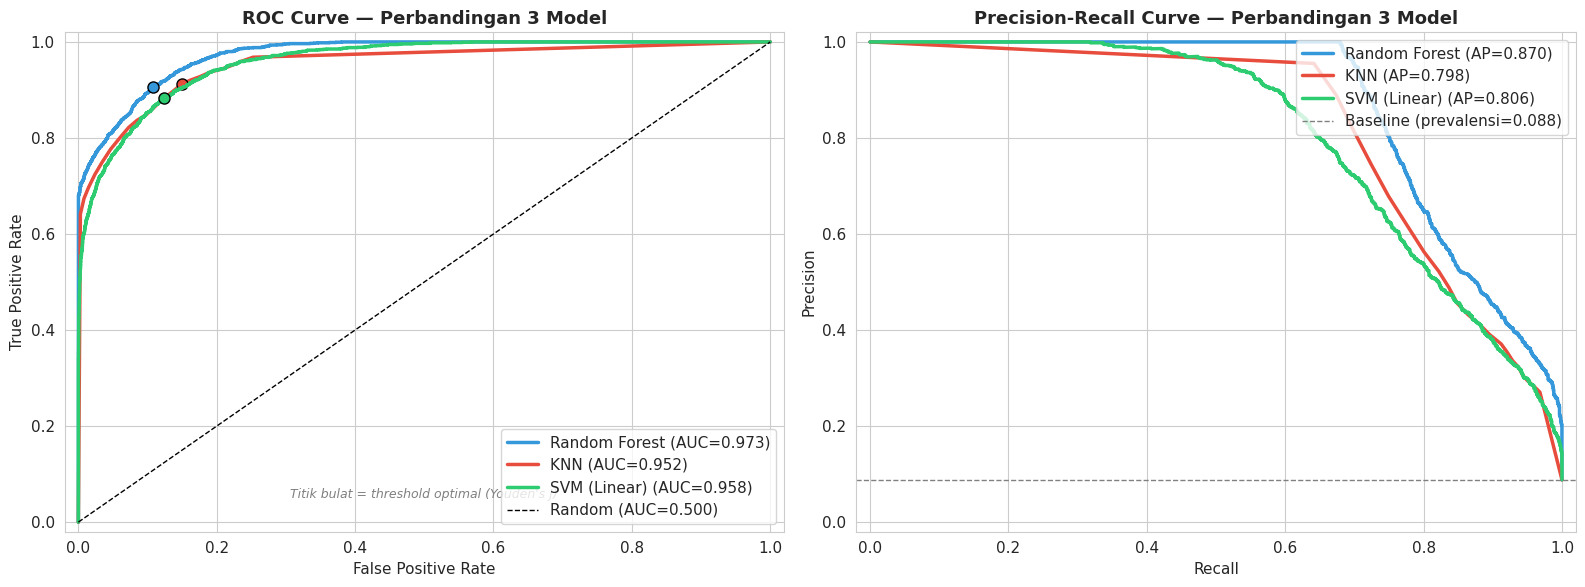

In [20]:
# ============================================================
# CELL 18: Visualisasi ROC Curve + Precision-Recall Curve
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_specs = [
    ('Random Forest', rf_proba,  '#3498db', rf_result['threshold']),
    ('KNN',           knn_proba, '#e74c3c', knn_result['threshold']),
    ('SVM (Linear)',  svm_proba, '#2ecc71', svm_result['threshold']),
]

# --- ROC Curve ---
ax = axes[0]
for name, proba, color, thr in model_specs:
    fpr, tpr, thr_arr = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC={roc_auc:.3f})')

    # Tandai titik optimal threshold
    y_pred_thr = (proba >= thr).astype(int)
    fp_rate = (y_pred_thr[y_test==0]==1).sum() / (y_test==0).sum()
    tp_rate = (y_pred_thr[y_test==1]==1).sum() / (y_test==1).sum()
    ax.plot(fp_rate, tp_rate, 'o', color=color, markersize=8, markeredgecolor='black')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Perbandingan 3 Model', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.text(0.5, 0.05, 'Titik bulat = threshold optimal (Youden\'s J)',
        ha='center', fontsize=9, style='italic', color='gray')

# --- Precision-Recall Curve ---
ax = axes[1]
baseline = (y_test == 1).sum() / len(y_test)
for name, proba, color, _ in model_specs:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=color, lw=2.5, label=f'{name} (AP={ap:.3f})')

ax.axhline(y=baseline, color='gray', linestyle='--', lw=1,
           label=f'Baseline (prevalensi={baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Perbandingan 3 Model', fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig('eval_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

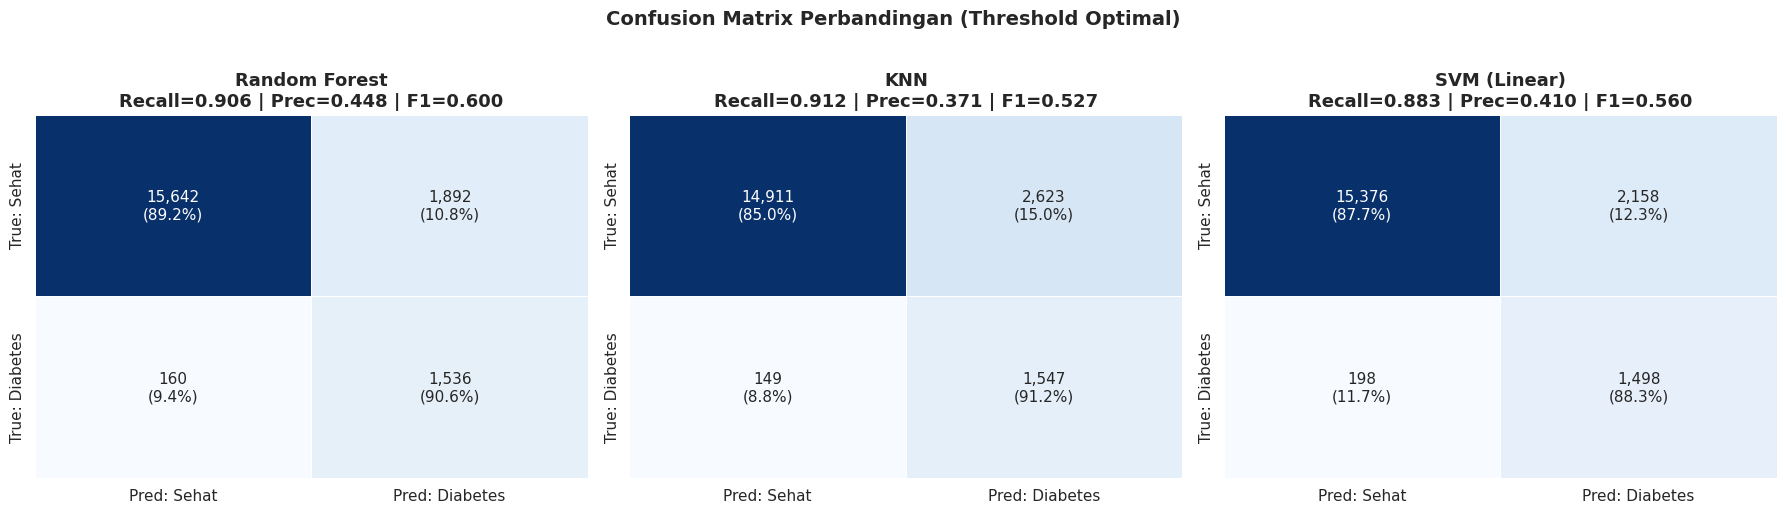

In [21]:
# ============================================================
# CELL 19: Confusion Matrix — 3 Model
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_preds = [
    ('Random Forest', rf_pred,  '#3498db'),
    ('KNN',           knn_pred, '#e74c3c'),
    ('SVM (Linear)',  svm_pred, '#2ecc71'),
]

for ax, (name, y_pred, color) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    annot = np.array([[f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)'
                       for j in range(2)] for i in range(2)])

    sns.heatmap(
        cm, annot=annot, fmt='', cmap='Blues', ax=ax,
        xticklabels=['Pred: Sehat', 'Pred: Diabetes'],
        yticklabels=['True: Sehat', 'True: Diabetes'],
        linewidths=0.5, linecolor='white',
        cbar=False
    )

    # Metrics
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    ax.set_title(f'{name}\nRecall={rec:.3f} | Prec={prec:.3f} | F1={f1:.3f}',
                 fontweight='bold')

plt.suptitle('Confusion Matrix Perbandingan (Threshold Optimal)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

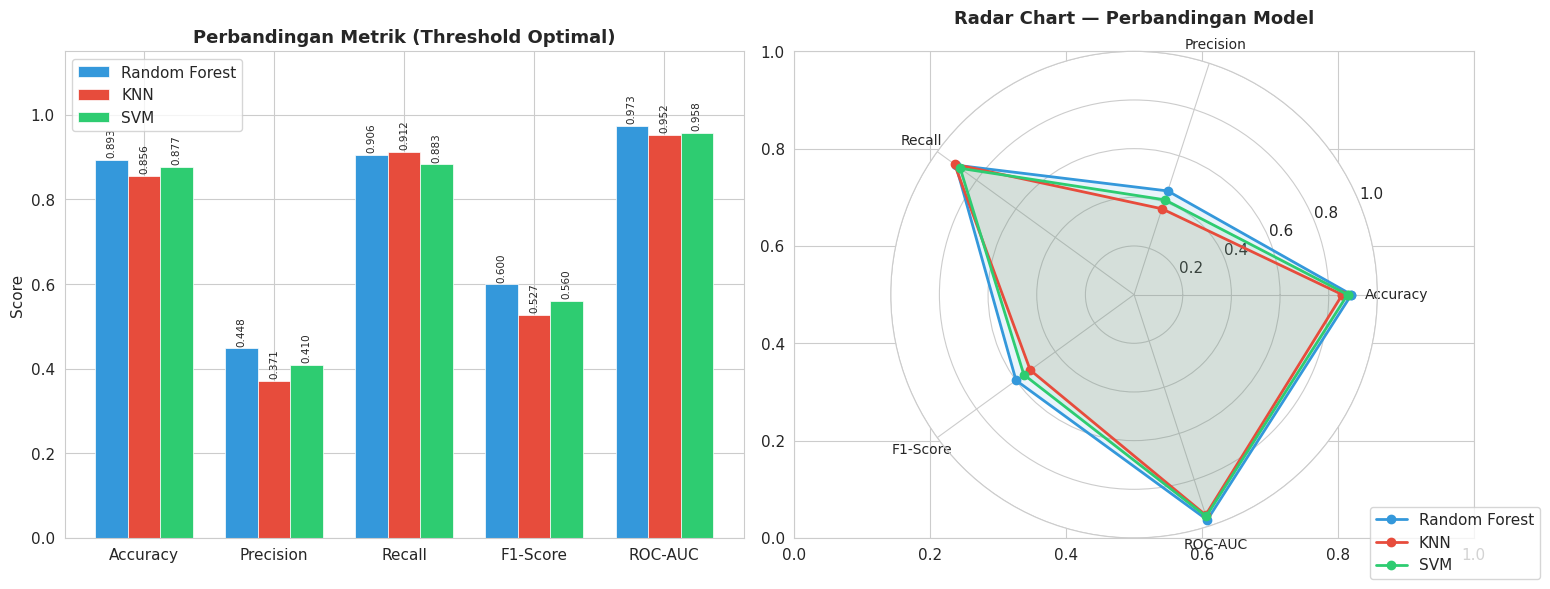

In [22]:
# ============================================================
# CELL 20: Bar Chart — Perbandingan Metrik Semua Model
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metric_keys_t = ['accuracy_tuned', 'precision_tuned', 'recall_tuned', 'f1_tuned', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names   = ['Random Forest', 'KNN', 'SVM']
colors        = ['#3498db', '#e74c3c', '#2ecc71']

x = np.arange(len(metric_labels))
width = 0.25

# Grouped bar chart
ax = axes[0]
for i, (result, color, name) in enumerate(zip(results, colors, model_names)):
    vals = [result[k] for k in metric_keys_t]
    bars = ax.bar(x + i*width, vals, width, label=name, color=color,
                  edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=90)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik (Threshold Optimal)', fontweight='bold')
ax.legend()

# Radar chart
ax2 = axes[1]
categories = metric_labels
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax2 = plt.subplot(122, projection='polar')
for result, color, name in zip(results, colors, model_names):
    vals = [result[k] for k in metric_keys_t]
    vals += vals[:1]
    ax2.plot(angles, vals, 'o-', linewidth=2, color=color, label=name)
    ax2.fill(angles, vals, alpha=0.1, color=color)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_title('Radar Chart — Perbandingan Model', fontweight='bold', pad=20)
ax2.legend(loc='lower right', bbox_to_anchor=(1.35, -0.1))

plt.tight_layout()
plt.savefig('eval_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ============================================================
# CELL 21: Benchmark — Waktu Training & Inference
# ============================================================

# Inference time
n_test = len(X_test)

t0 = time.time(); _ = best_rf.predict_proba(X_test);  rf_infer  = (time.time()-t0)*1000
t0 = time.time(); _ = best_knn.predict_proba(X_test); knn_infer = (time.time()-t0)*1000
t0 = time.time(); _ = best_svm.predict_proba(X_test); svm_infer = (time.time()-t0)*1000

benchmark = pd.DataFrame({
    'Model'              : ['Random Forest', 'KNN', 'SVM (Linear)'],
    'Training Time (s)'  : [f'{rf_train_time:.1f}', f'{knn_train_time:.1f}', f'{svm_train_time:.1f}'],
    'Inference Time (ms)': [f'{rf_infer:.0f}', f'{knn_infer:.0f}', f'{svm_infer:.0f}'],
    f'Inference/sample (ms)': [
        f'{rf_infer/n_test:.3f}',
        f'{knn_infer/n_test:.3f}',
        f'{svm_infer/n_test:.3f}'
    ]
})

print('BENCHMARK WAKTU KOMPUTASI')
print('=' * 65)
display(benchmark.set_index('Model'))

BENCHMARK WAKTU KOMPUTASI


,Training Time (s),Inference Time (ms),Inference/sample (ms)
Model,,,
Random Forest,5132.6,353,0.018
KNN,539.1,1550,0.081
SVM (Linear),32.1,7,0.000


In [24]:
# ============================================================
# CELL 22: McNemar's Statistical Significance Test
# ============================================================

def mcnemar_test(y_true, pred_a, pred_b, name_a, name_b):
    """
    Uji signifikansi perbedaan dua model dengan McNemar's Test.
    H0: Kedua model memiliki performa yang sama.
    """
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)

    # b = A benar, B salah
    b = np.sum(correct_a & ~correct_b)
    # c = A salah, B benar
    c = np.sum(~correct_a & correct_b)

    table = [[0, b], [c, 0]]
    result = mcnemar(table, exact=False, correction=True)

    sig = 'SIGNIFIKAN' if result.pvalue < 0.05 else 'TIDAK signifikan'
    print(f'  {name_a} vs {name_b}:')
    print(f'    b={b:,}, c={c:,} | chi2={result.statistic:.4f} | p-value={result.pvalue:.6f}')
    print(f'    Kesimpulan: {sig} (alpha=0.05)')
    print()
    return result.pvalue

print('McNEMAR\'S STATISTICAL SIGNIFICANCE TEST')
print('=' * 60)
print('H0: Dua model tidak berbeda secara statistik')
print('H1: Dua model berbeda secara statistik')
print('Alpha = 0.05')
print()

p_rf_knn = mcnemar_test(y_test, rf_pred, knn_pred, 'Random Forest', 'KNN')
p_rf_svm = mcnemar_test(y_test, rf_pred, svm_pred, 'Random Forest', 'SVM')
p_knn_svm = mcnemar_test(y_test, knn_pred, svm_pred, 'KNN', 'SVM')

print('Ringkasan:')
summary_mc = pd.DataFrame({
    'Perbandingan': ['RF vs KNN', 'RF vs SVM', 'KNN vs SVM'],
    'p-value': [p_rf_knn, p_rf_svm, p_knn_svm],
    'Signifikan (p<0.05)': [
        'Ya' if p < 0.05 else 'Tidak'
        for p in [p_rf_knn, p_rf_svm, p_knn_svm]
    ]
})
display(summary_mc.set_index('Perbandingan'))

McNEMAR'S STATISTICAL SIGNIFICANCE TEST
H0: Dua model tidak berbeda secara statistik
H1: Dua model berbeda secara statistik
Alpha = 0.05

  Random Forest vs KNN:
    b=1,076, c=356 | chi2=361.0063 | p-value=0.000000
    Kesimpulan: SIGNIFIKAN (alpha=0.05)

  Random Forest vs SVM:
    b=915, c=611 | chi2=60.1632 | p-value=0.000000
    Kesimpulan: SIGNIFIKAN (alpha=0.05)

  KNN vs SVM:
    b=775, c=1,191 | chi2=87.6017 | p-value=0.000000
    Kesimpulan: SIGNIFIKAN (alpha=0.05)

Ringkasan:


,p-value,Signifikan (p<0.05)
Perbandingan,,
RF vs KNN,1.700079e-80,Ya
RF vs SVM,8.731066e-15,Ya
KNN vs SVM,8.005462e-21,Ya


In [25]:
# ============================================================
# CELL 23: Cross-Validation Score Summary
# ============================================================

print('CROSS-VALIDATION SUMMARY (5-Fold Stratified)')
print('=' * 60)

cv_rows = []
for name, search in [('Random Forest', rf_search), ('KNN', knn_search), ('SVM', svm_search)]:
    cv_res = search.cv_results_
    best_idx = search.best_index_
    cv_rows.append({
        'Model'          : name,
        'Recall CV Mean' : f"{cv_res['mean_test_score'][best_idx]:.4f}",
        'Recall CV Std'  : f"{cv_res['std_test_score'][best_idx]:.4f}",
        'Train Recall'   : f"{cv_res['mean_train_score'][best_idx]:.4f}",
        'Overfit Gap'    : f"{cv_res['mean_train_score'][best_idx] - cv_res['mean_test_score'][best_idx]:.4f}",
    })

df_cv = pd.DataFrame(cv_rows)
display(df_cv.set_index('Model'))
print()
print('Overfit Gap kecil (<0.05) = model generalisasi dengan baik.')

CROSS-VALIDATION SUMMARY (5-Fold Stratified)


,Recall CV Mean,Recall CV Std,Train Recall,Overfit Gap
Model,,,,
Random Forest,0.9024,0.0118,0.9151,0.0126
KNN,0.8803,0.0064,0.9657,0.0853
SVM,0.8843,0.0113,0.8840,-0.0003



Overfit Gap kecil (<0.05) = model generalisasi dengan baik.


---
# TAHAP 5: Explainable AI (XAI) — Model Terbaik

XAI diterapkan **hanya pada model terbaik** untuk efisiensi komputasi.
- Jika Random Forest (RF) adalah best model: gunakan **TreeSHAP** (cepat & akurat)
- **LIME** untuk penjelasan level instance (individual prediction)


In [26]:
# ============================================================
# CELL 24: Identifikasi Model Terbaik
# ============================================================

# Bandingkan Recall (metrik utama dalam konteks medis)
recalls = {
    'Random Forest': rf_result['recall_tuned'],
    'KNN'          : knn_result['recall_tuned'],
    'SVM (Linear)' : svm_result['recall_tuned'],
}

best_model_name = max(recalls, key=recalls.get)
best_model_obj  = {'Random Forest': best_rf,
                   'KNN': best_knn,
                   'SVM (Linear)': best_svm}[best_model_name]

print('IDENTIFIKASI MODEL TERBAIK')
print('=' * 45)
for name, rec in recalls.items():
    marker = ' << TERBAIK' if name == best_model_name else ''
    print(f'  {name:<18}: Recall = {rec:.4f}{marker}')
print(f'\nModel terbaik  : {best_model_name}')
print(f'Recall         : {recalls[best_model_name]:.4f}')
print(f'ROC-AUC        : {rf_result["roc_auc"] if best_model_name=="Random Forest" else (knn_result["roc_auc"] if best_model_name=="KNN" else svm_result["roc_auc"]):.4f}')
print()
print(f'XAI akan diterapkan pada: {best_model_name}')

IDENTIFIKASI MODEL TERBAIK
  Random Forest     : Recall = 0.9057
  KNN               : Recall = 0.9121 << TERBAIK
  SVM (Linear)      : Recall = 0.8833

Model terbaik  : KNN
Recall         : 0.9121
ROC-AUC        : 0.9524

XAI akan diterapkan pada: KNN


[INFO] Model KNN → menggunakan Permutation Importance


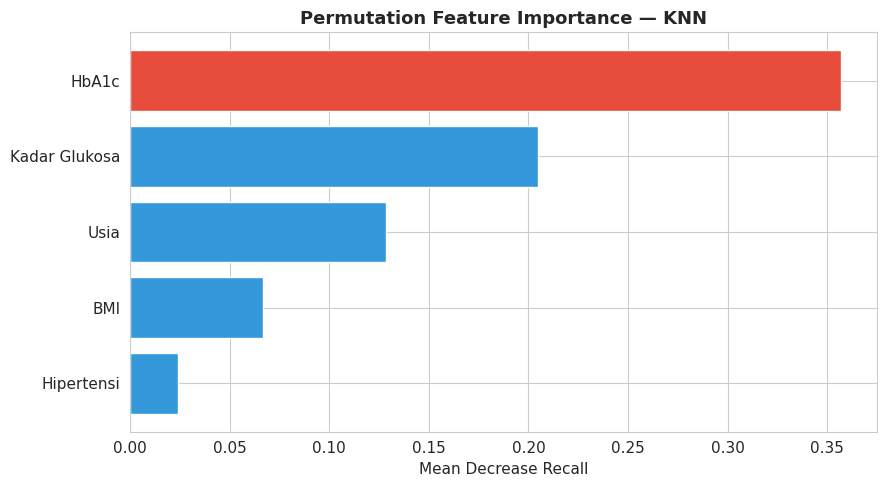


Feature Importance Ranking (Mean Decrease Recall):
  #1: HbA1c                (Mean Decrease Recall = 0.3571)
  #2: Kadar Glukosa        (Mean Decrease Recall = 0.2048)
  #3: Usia                 (Mean Decrease Recall = 0.1286)
  #4: BMI                  (Mean Decrease Recall = 0.0667)
  #5: Hipertensi           (Mean Decrease Recall = 0.0238)

Ekspektasi domain medis: HbA1c & Kadar Glukosa harus di posisi #1 atau #2.


In [36]:
# ============================================================
# CELL 25: SHAP Analysis + Permutation Importance Fallback
# ============================================================
import shap
from sklearn.inspection import permutation_importance

scaler_fitted = best_model_obj.named_steps['scaler']
clf_fitted    = best_model_obj.named_steps['clf']
X_test_scaled = scaler_fitted.transform(X_test)

np.random.seed(RANDOM_STATE)
shap_idx = np.random.choice(len(X_test_scaled), size=1000, replace=False)
X_shap   = X_test_scaled[shap_idx]

if best_model_name == 'Random Forest':
    # ── TreeSHAP (cepat & akurat untuk RF) ──
    explainer          = shap.TreeExplainer(clf_fitted)
    shap_values        = explainer.shap_values(X_shap)
    shap_vals_diabetes = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals_diabetes, X_shap,
                      feature_names=FEATURE_LABELS, show=False, plot_type='dot')
    plt.title(f'SHAP Summary Plot — {best_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(9, 5))
    shap.summary_plot(shap_vals_diabetes, X_shap,
                      feature_names=FEATURE_LABELS, show=False, plot_type='bar')
    plt.title(f'SHAP Mean |SHAP| — Feature Importance ({best_model_name})', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    mean_abs_shap   = np.abs(shap_vals_diabetes).mean(axis=0)
    feat_importance = sorted(zip(FEATURE_LABELS, mean_abs_shap),
                             key=lambda x: x[1], reverse=True)
    label_importance = 'mean |SHAP|'

else:
    # ── Permutation Importance untuk KNN / SVM (KernelSHAP tidak reliable) ──
    print(f"[INFO] Model {best_model_name} → menggunakan Permutation Importance")
    perm = permutation_importance(
        best_model_obj, X_test[:500], y_test[:500],  # ← subsample 500 saja
        n_repeats=5,                                   # ← dari 30 → 5
        scoring='recall',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    mean_abs_shap   = perm.importances_mean  # nama variabel disamakan
    feat_importance = sorted(zip(FEATURE_LABELS, mean_abs_shap),
                             key=lambda x: x[1], reverse=True)
    label_importance = 'Mean Decrease Recall'

    feats_sorted = [x[0] for x in feat_importance]
    vals_sorted  = [x[1] for x in feat_importance]
    colors = ['#e74c3c' if v == max(vals_sorted) else '#3498db' for v in vals_sorted]

    plt.figure(figsize=(9, 5))
    plt.barh(feats_sorted[::-1], vals_sorted[::-1], color=colors[::-1], edgecolor='white')
    plt.xlabel(label_importance)
    plt.title(f'Permutation Feature Importance — {best_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Validasi Domain Knowledge ──
print(f'\nFeature Importance Ranking ({label_importance}):')
for rank, (feat, val) in enumerate(feat_importance, 1):
    print(f'  #{rank}: {feat:<20} ({label_importance} = {val:.4f})')
print('\nEkspektasi domain medis: HbA1c & Kadar Glukosa harus di posisi #1 atau #2.')

In [37]:
# ============================================================
# CELL 26: SHAP Dependence Plot — HbA1c & Kadar Glukosa
# ============================================================

if best_model_name == 'Random Forest':
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # HbA1c
    hba1c_idx = FEATURE_LABELS.index('HbA1c')
    gluc_idx  = FEATURE_LABELS.index('Kadar Glukosa')

    shap.dependence_plot(
        hba1c_idx,
        shap_vals_diabetes,
        X_shap,
        feature_names=FEATURE_LABELS,
        ax=axes[0],
        show=False,
        interaction_index=gluc_idx
    )
    axes[0].set_title('SHAP Dependence: HbA1c\n(warna = Kadar Glukosa)', fontweight='bold')

    # Kadar Glukosa
    shap.dependence_plot(
        gluc_idx,
        shap_vals_diabetes,
        X_shap,
        feature_names=FEATURE_LABELS,
        ax=axes[1],
        show=False,
        interaction_index=hba1c_idx
    )
    axes[1].set_title('SHAP Dependence: Kadar Glukosa\n(warna = HbA1c)', fontweight='bold')

    plt.tight_layout()
    plt.savefig('shap_dependence_plots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Grafik menunjukkan threshold kritis HbA1c dan Glukosa yang mempengaruhi prediksi diabetes.')
else:
    print(f'Dependence plot dioptimalkan untuk TreeSHAP (Random Forest). Model terbaik: {best_model_name}.')

Dependence plot dioptimalkan untuk TreeSHAP (Random Forest). Model terbaik: KNN.



=== True Positive  (Diabetes terdeteksi BENAR) ===
  Label Sebenarnya : Diabetes
  Prediksi Model   : Diabetes
  Probabilitas     : 1.0000
  Top Fitur (LIME) :
    [+] Kadar Glukosa > 0.56: 0.1535
    [-] Hipertensi <= -0.29: 0.0946
    [-] -0.69 < HbA1c <= 0.26: 0.0720
    [+] BMI > 0.48: 0.0647
    [+] 0.06 < Usia <= 0.77: 0.0504


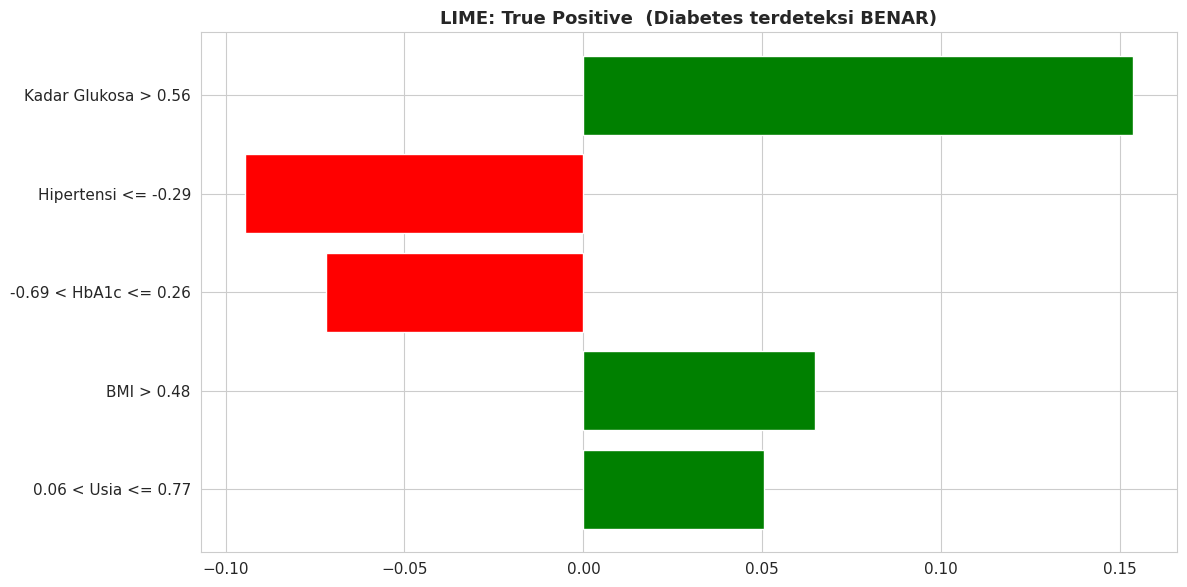


=== False Negative (Diabetes TIDAK terdeteksi — kasus kritis!) ===
  Label Sebenarnya : Diabetes
  Prediksi Model   : Sehat
  Probabilitas     : 0.1905
  Top Fitur (LIME) :
    [+] Usia > 0.77: 0.1454
    [-] Hipertensi <= -0.29: 0.0964
    [-] -0.69 < HbA1c <= 0.26: 0.0651
    [+] 0.07 < Kadar Glukosa <= 0.56: 0.0457
    [+] 0.05 < BMI <= 0.48: 0.0121


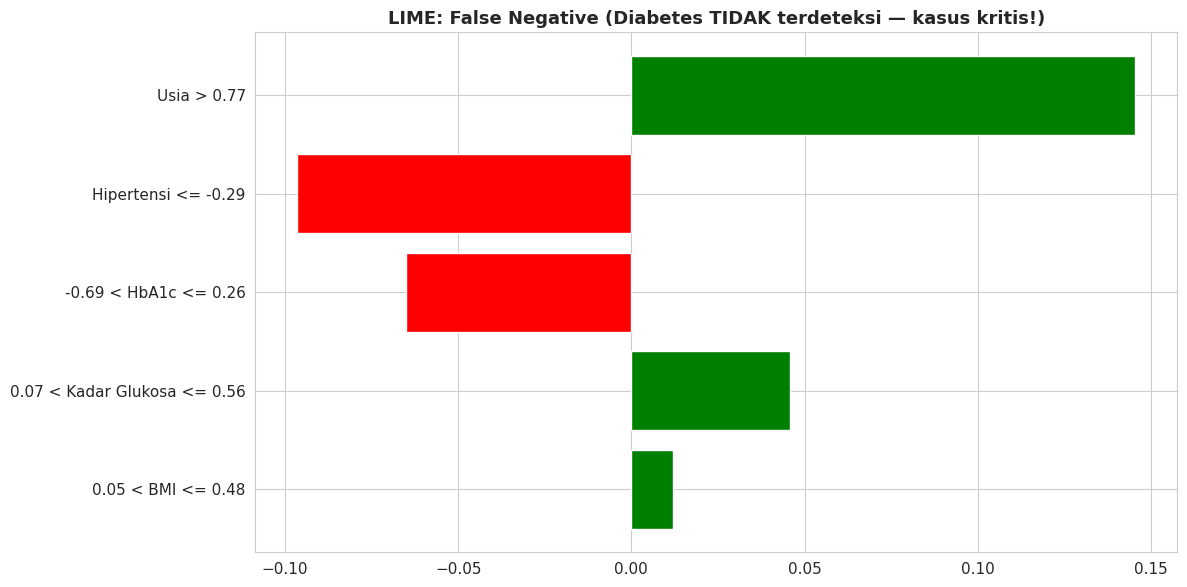


=== True Negative  (Sehat terdeteksi benar) ===
  Label Sebenarnya : Sehat
  Prediksi Model   : Sehat
  Probabilitas     : 0.1905
  Top Fitur (LIME) :
    [+] HbA1c > 0.65: 0.3319
    [-] Hipertensi <= -0.29: 0.0876
    [+] BMI > 0.48: 0.0556
    [+] 0.07 < Kadar Glukosa <= 0.56: 0.0536
    [+] 0.06 < Usia <= 0.77: 0.0426


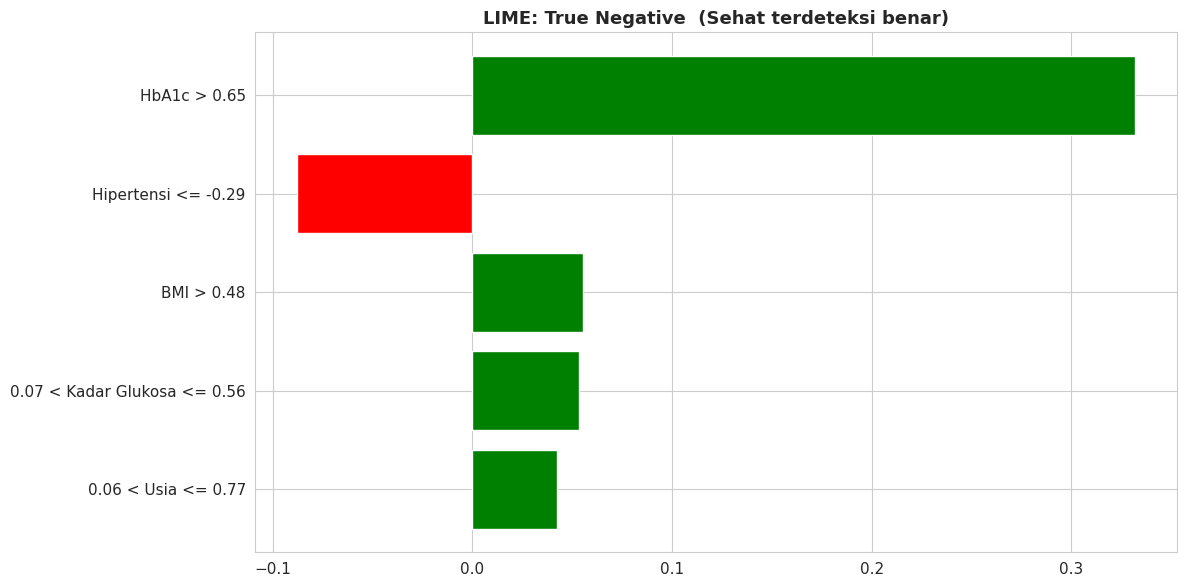

In [38]:
# ============================================================
# CELL 27: LIME Analysis — 3 Kasus Representatif
# ============================================================

import lime
import lime.lime_tabular

# Setup LIME explainer menggunakan training data yang sudah di-scale
X_train_scaled_lime = scaler_fitted.transform(X_train)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train_scaled_lime,
    feature_names  = FEATURE_LABELS,
    class_names    = ['Sehat', 'Diabetes'],
    mode           = 'classification',
    random_state   = RANDOM_STATE
)

# Prediksi function (sudah menerima scaled data dari LIME)
def predict_fn_scaled(X_scaled):
    """LIME memanggil ini dengan scaled data — langsung ke classifier."""
    return clf_fitted.predict_proba(X_scaled)

# Pilih 3 kasus dari test set
best_proba = best_model_obj.named_steps['clf'].predict_proba(X_test_scaled)[:, 1]
best_pred  = (best_proba >= rf_result['threshold']).astype(int) if best_model_name == 'Random Forest' else \
             (best_proba >= knn_result['threshold']).astype(int) if best_model_name == 'KNN' else \
             (best_proba >= svm_result['threshold']).astype(int)

y_test_arr = y_test.values
tp_idx = np.where((best_pred == 1) & (y_test_arr == 1))[0][0]  # True Positive
fn_idx = np.where((best_pred == 0) & (y_test_arr == 1))[0][0]  # False Negative
tn_idx = np.where((best_pred == 0) & (y_test_arr == 0))[0][0]  # True Negative

cases = [
    (tp_idx, 'True Positive  (Diabetes terdeteksi BENAR)'),
    (fn_idx, 'False Negative (Diabetes TIDAK terdeteksi — kasus kritis!)'),
    (tn_idx, 'True Negative  (Sehat terdeteksi benar)'),
]

for idx, case_name in cases:
    print(f'\n=== {case_name} ===')
    instance = X_test_scaled[idx]
    exp = lime_explainer.explain_instance(
        instance,
        predict_fn_scaled,
        num_features=5,
        top_labels=2
    )
    print(f'  Label Sebenarnya : {"Diabetes" if y_test_arr[idx]==1 else "Sehat"}')
    print(f'  Prediksi Model   : {"Diabetes" if best_pred[idx]==1 else "Sehat"}')
    print(f'  Probabilitas     : {best_proba[idx]:.4f}')
    print(f'  Top Fitur (LIME) :')
    for feat, weight in exp.as_list(label=1):
        direction = '+' if weight > 0 else '-'
        print(f'    [{direction}] {feat}: {abs(weight):.4f}')
    # Simpan gambar LIME
    fname = f'lime_{case_name.split("(")[0].strip().lower().replace(" ","_")}.png'
    exp.as_pyplot_figure(label=1)
    plt.title(f'LIME: {case_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

---
# Ringkasan Akhir & Kesimpulan


In [39]:
# ============================================================
# CELL 28: Ringkasan Akhir Sistem
# ============================================================

print('=' * 70)
print('  RINGKASAN AKHIR: PREDIKSI DIABETES — RF vs KNN vs SVM')
print('=' * 70)

print(f'\nDataset        : {len(df_clean):,} data, 5 fitur kunci')
print(f'Fitur          : {SELECTED_FEATURES}')
print(f'Imbalanced     : SMOTE di dalam ImbPipeline (no leakage)')
print(f'Threshold      : Youden\'s J Statistic (per model)')

print(f'\n{"Model":<18} {"Recall":>8} {"Precision":>10} {"F1":>8} {"ROC-AUC":>9}')
print('-' * 60)
for r in results:
    print(f'{r["model"]:<18} {r["recall_tuned"]:>8.4f} {r["precision_tuned"]:>10.4f} '
          f'{r["f1_tuned"]:>8.4f} {r["roc_auc"]:>9.4f}')

print(f'\nModel Terbaik  : {best_model_name} (berdasarkan Recall tertinggi)')
print(f'XAI            : SHAP (global) + LIME (per instance) pada {best_model_name}')

print(f'\nKesimpulan XAI (validasi domain medis):')
for rank, (feat, val) in enumerate(feat_importance[:3], 1):
    print(f'  #{rank}: {feat} (mean |SHAP| = {val:.4f})')

print()
print('Studi ini menunjukkan perbandingan komprehensif ketiga algoritma')
print('dengan metodologi yang bebas dari data leakage.')
print('=' * 70)

  RINGKASAN AKHIR: PREDIKSI DIABETES — RF vs KNN vs SVM

Dataset        : 96,146 data, 5 fitur kunci
Fitur          : ['age', 'bmi', 'hypertension', 'HbA1c_level', 'blood_glucose_level']
Imbalanced     : SMOTE di dalam ImbPipeline (no leakage)
Threshold      : Youden's J Statistic (per model)

Model                Recall  Precision       F1   ROC-AUC
------------------------------------------------------------
Random Forest        0.9057     0.4481   0.5995    0.9733
KNN                  0.9121     0.3710   0.5274    0.9524
SVM (Linear)         0.8833     0.4097   0.5598    0.9581

Model Terbaik  : KNN (berdasarkan Recall tertinggi)
XAI            : SHAP (global) + LIME (per instance) pada KNN

Kesimpulan XAI (validasi domain medis):
  #1: HbA1c (mean |SHAP| = 0.3571)
  #2: Kadar Glukosa (mean |SHAP| = 0.2048)
  #3: Usia (mean |SHAP| = 0.1286)

Studi ini menunjukkan perbandingan komprehensif ketiga algoritma
dengan metodologi yang bebas dari data leakage.
